# Activity 2.3 - CNN Network Architectures

#### Objective(s):

This activity aims to introduce how to use CNN network architectures

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to use pretrained model in predicting the object
* Evaluate the accuracy of each pretrained model

#### Resources:
* Jupyter Notebook
* MNIST

#### Procedures
Load the necessary libraries

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# install opencv if you haven't
# pip install opencv-python
# pip install pillow

In [46]:
from PIL import Image
from keras.preprocessing import image
import numpy as np
import pandas as pd

import cv2
import imageio.v2 as imageio # Changed

import matplotlib.pyplot as plt

Create a function that will capture and save the image from your webcam

In [6]:
def get_image(camera):
    retval, im = camera.read()
    return im

In [7]:
def save_webcam_image(img_path):

    try:
        camera_port = 0
        ramp_frames = 10

        camera = cv2.VideoCapture(camera_port)

        for i in range(ramp_frames):
            retval, im_camera = camera.read()

        retval, im_camera = camera.read()

        im = cv2.resize(im_camera, (224, 224)).astype(np.float32)
        cv2.imwrite(img_path, im)
        del (camera)
        return True
    except ValueError as e:
        print("Image Capture Failed")
    return False

* Test your function.
* Place a clock or any object
* Display the saved image

In [32]:
img_path = "/content/drive/MyDrive/CPE 313-CPE32S3 - Advanced Machine Learning and Deep Learning/Hands-on Activity 3.2 CNN Network Architectures/Dog_Breeds.jpg"
image = cv2.imread(file_path)
print(image.shape)

(825, 1100, 3)


In [20]:
new_image = cv2.resize(image, (224, 224))

array([[[ 48,  78,  43],
        [ 48,  78,  43],
        [ 48,  78,  43],
        ...,
        [ 19,  26,   4],
        [ 18,  24,   5],
        [ 18,  24,   5]],

       [[ 48,  78,  43],
        [ 48,  78,  43],
        [ 48,  78,  43],
        ...,
        [ 18,  25,   4],
        [ 18,  24,   5],
        [ 17,  23,   4]],

       [[ 48,  78,  43],
        [ 48,  78,  43],
        [ 48,  78,  43],
        ...,
        [ 17,  24,   3],
        [ 17,  23,   4],
        [ 16,  22,   3]],

       ...,

       [[ 47, 137, 101],
        [ 47, 142, 105],
        [ 45, 141, 104],
        ...,
        [ 41, 143, 101],
        [ 40, 143, 101],
        [ 40, 143, 101]],

       [[ 44, 139, 102],
        [ 46, 142, 103],
        [ 42, 141, 103],
        ...,
        [ 44, 144, 102],
        [ 40, 144, 103],
        [ 39, 144, 101]],

       [[ 45, 142,  98],
        [ 42, 143,  98],
        [ 40, 143,  98],
        ...,
        [ 43, 145, 103],
        [ 40, 147, 104],
        [ 38, 146, 103]]], dtype=uint8)
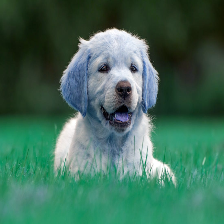

In [22]:
new_image

In [31]:
img_path = new_image

if save_webcam_image(img_path) is False:
    # Webcam not active, use the Dog Image
    img_path = new_image
    print("Using the Test Image: {}".format(img_path))

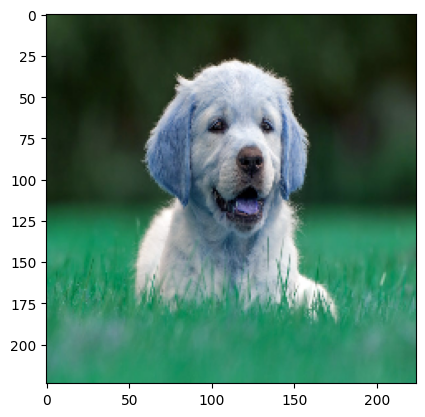

In [30]:
plt.imshow(new_image)

Use VGG-16 pre-trained model

In [31]:
from keras.applications import vgg16


vgg16_model = vgg16.VGG16(weights='imagenet')
vgg16_model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

Create a function to load model, image, preprocess input and targets

In [48]:
def predict_image(model, img_path, preprocess_input_fn, decode_predictions_fn, target_size=(224, 224)):

    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input_fn(x)

    preds = model.predict(x)
    predictions_df = pd.DataFrame(decode_predictions_fn(preds, top=10)[0])
    predictions_df.columns = ["Predicted Class", "Name", "Probability"]
    return predictions_df

Predict the result

In [49]:
predict_image(vgg16_model, img_path, vgg16.preprocess_input, vgg16.decode_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Predicted Class,Name,Probability
0,n02099601,golden_retriever,0.859459
1,n02104029,kuvasz,0.035100
2,n02111500,Great_Pyrenees,0.027270
3,n02101556,clumber,0.013389
4,n02108551,Tibetan_mastiff,0.009823
5,n02099712,Labrador_retriever,0.007913
6,n02091635,otterhound,0.005833
7,n02109525,Saint_Bernard,0.005521
8,n02111129,Leonberg,0.004369
9,n02102480,Sussex_spaniel,0.003602


Interpret the result of prediction using VGG16 model

**Answer:**
- The results were really accurate. It showed that the model classified the image as a golden retriever with a probability of 85%. The rest of the prediction are sub 3%, which indicates that theres a very low chance that the picture is not a golden retriever.

Use Resnet50 pretrained model

In [50]:
from keras.applications import resnet50

resnet50_model = resnet50.ResNet50(weights='imagenet')

resnet50_model.summary()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

Predict the result

In [51]:
predict_image(resnet50_model, img_path, resnet50.preprocess_input, resnet50.decode_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


,Predicted Class,Name,Probability
0,n02099601,golden_retriever,0.931403
1,n02099712,Labrador_retriever,0.051530
2,n02101556,clumber,0.005380
3,n02104029,kuvasz,0.005113
4,n02111500,Great_Pyrenees,0.002083
5,n02091635,otterhound,0.002051
6,n02108551,Tibetan_mastiff,0.000417
7,n02111129,Leonberg,0.000345
8,n02097474,Tibetan_terrier,0.000253
9,n04409515,tennis_ball,0.000211


Interpret the result using RESNET50 pretrained model

**Answer:**
- The results of the RESNET50 model showed far more accurate and high results than the VGG-16 model. It identified the image as a Golden Retriever witha very high 93%. This model is more accurate and reliable than the VGG-16.

#### Supplementary Activity

* Use at least three pretrained model and predict the result using the saved image.
* Compare their accuracy results.

#### EfficientNet

In [79]:
from tensorflow.keras.applications import efficientnet

model = EfficientNetB0(weights='imagenet')

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = efficientnet.preprocess_input(x)

preds = model.predict(x)
predictions_df = pd.DataFrame(efficientnet.decode_predictions(preds, top=10)[0])
predictions_df.columns = ["Predicted Class", "Name", "Probability"]
predictions_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


,Predicted Class,Name,Probability
0,n02099601,golden_retriever,0.522401
1,n02104029,kuvasz,0.091551
2,n02099712,Labrador_retriever,0.083193
3,n02101556,clumber,0.047799
4,n02091635,otterhound,0.020156
5,n02111500,Great_Pyrenees,0.012430
6,n02113799,standard_poodle,0.008290
7,n02101388,Brittany_spaniel,0.005021
8,n02097474,Tibetan_terrier,0.004245
9,n02109525,Saint_Bernard,0.003897


#### DenseNet

In [91]:
predict_image(DenseNet121, img_path, densenet.preprocess_input, densenet.decode_predictions, target_size=(224, 224))

AttributeError: 'function' object has no attribute 'predict'

In [81]:
from tensorflow.keras.applications import densenet

model = DenseNet121(weights='imagenet')

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = densenet.preprocess_input(x)

preds = model.predict(x)
predictions_df = pd.DataFrame(densenet.decode_predictions(preds, top=10)[0])
predictions_df.columns = ["Predicted Class", "Name", "Probability"]
predictions_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


,Predicted Class,Name,Probability
0,n02099601,golden_retriever,0.825962
1,n02099712,Labrador_retriever,0.101270
2,n02111500,Great_Pyrenees,0.011295
3,n02104029,kuvasz,0.011208
4,n02091635,otterhound,0.008139
5,n02101556,clumber,0.005811
6,n04409515,tennis_ball,0.004753
7,n02108551,Tibetan_mastiff,0.003216
8,n02951358,canoe,0.002902
9,n02111277,Newfoundland,0.002855


#### NASNet

In [86]:
from tensorflow.keras.applications import nasnet

model = NASNetMobile(weights='imagenet')

img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = nasnet.preprocess_input(x)

preds = model.predict(x)
predictions_df = pd.DataFrame(nasnet.decode_predictions(preds, top=10)[0])
predictions_df.columns = ["Predicted Class", "Name", "Probability"]
predictions_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step


,Predicted Class,Name,Probability
0,n02099601,golden_retriever,0.806607
1,n02099712,Labrador_retriever,0.051209
2,n02104029,kuvasz,0.016327
3,n02101556,clumber,0.006848
4,n02102318,cocker_spaniel,0.003128
5,n04409515,tennis_ball,0.002957
6,n02111500,Great_Pyrenees,0.002618
7,n02091635,otterhound,0.002283
8,n02099267,flat-coated_retriever,0.002055
9,n02099429,curly-coated_retriever,0.001331


#### Conclusion

In this activity, I was able to learn about pre trained models and how to use them. Ive tried a total of 5 pretrained models in this activity. Out of everything I've tried, Resnet 50 was the model with the highest probability with 93%. The model with the lowest probability is Efficient net with 52% probabilty. The other 3 models hovered around 80% in their predictions.